In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
from sklearn.metrics import roc_auc_score, accuracy_score, recall_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import joblib 

In [2]:
# Step 1: Loading the Scaled Data
# Logistic Regression requires scaled features for gradient descent to converge properly.
train_data = pd.read_csv('../data/processed/train_scaled.csv')
test_data = pd.read_csv('../data/processed/test_scaled.csv')

X_train = train_data.drop(columns=['target'])
y_train = train_data['target']

X_test = test_data.drop(columns=['target'])
y_test = test_data['target']

print(f"Training Features (X_train) Shape: {X_train.shape}")
print(f"Testing Features (X_test) Shape: {X_test.shape}")

Training Features (X_train) Shape: (1949, 122)
Testing Features (X_test) Shape: (488, 122)


In [3]:

# Step 2: Model Initialization and Training
# max_iter=1000 ensures the algorithm has enough iterations to converge successfully
log_reg_model = LogisticRegression(max_iter=1000, random_state=42)
log_reg_model.fit(X_train, y_train)



,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [4]:

# Step 3: Making Predictions on Unseen Data

y_pred = log_reg_model.predict(X_test)

# Predict the probabilities (for ROC-AUC and confidence intervals)
# predict_proba returns two columns [prob_0, prob_1], we select [:, 1] to get the probability of being Malignant
y_pred_proba = log_reg_model.predict_proba(X_test)[:, 1]

print("--- Step 3: Predictions Generated ---")
print(f"First 5 Predictions (Classes): {y_pred[:5]}")
print(f"First 5 Probabilities: {np.round(y_pred_proba[:5], 3)}")

--- Step 3: Predictions Generated ---
First 5 Predictions (Classes): [0. 1. 0. 1. 1.]
First 5 Probabilities: [0.319 0.766 0.    0.51  0.958]


In [5]:
# Step 4: Model Evaluation
# calculatin metrics
accuracy = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred) # Kanserli (1) vakaları ne kadar yakaladık?
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"Accuracy : {accuracy:.4f}  --> (need to be >0.95)")
print(f"Recall : {recall:.4f}  --> (most important)")
print(f"F1-Score         : {f1:.4f}")
print(f"ROC-AUC          : {roc_auc:.4f}")

print("\n--- Detailed Classification Report ---")
print(classification_report(y_test, y_pred, target_names=['Benign (0)', 'Malignant (1)']))


Accuracy : 0.7664  --> (need to be >0.95)
Recall : 0.7136  --> (most important)
F1-Score         : 0.7273
ROC-AUC          : 0.8430

--- Detailed Classification Report ---
               precision    recall  f1-score   support

   Benign (0)       0.78      0.81      0.80       275
Malignant (1)       0.74      0.71      0.73       213

     accuracy                           0.77       488
    macro avg       0.76      0.76      0.76       488
 weighted avg       0.77      0.77      0.77       488



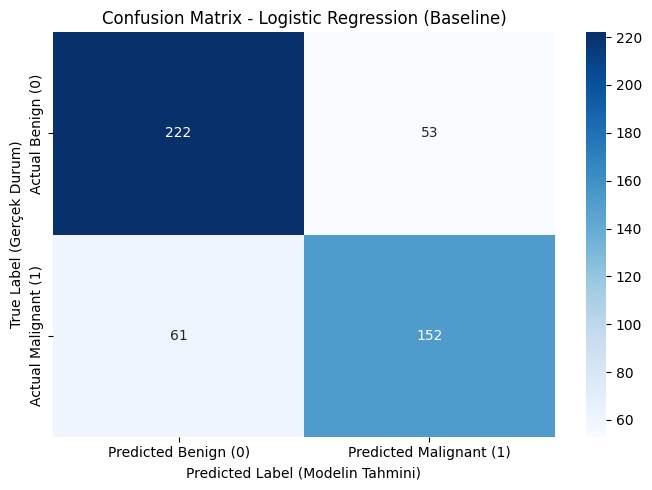

In [6]:

# ---------------------------------------------------------
# Step 5: Visualizing the Confusion Matrix
# ---------------------------------------------------------
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted Benign (0)', 'Predicted Malignant (1)'],
            yticklabels=['Actual Benign (0)', 'Actual Malignant (1)'])
plt.title('Confusion Matrix - Logistic Regression (Baseline)')
plt.ylabel('True Label (Gerçek Durum)')
plt.xlabel('Predicted Label (Modelin Tahmini)')
plt.tight_layout()

# Grafiği reports/figures/ klasörüne otomatik kaydetme
import os
os.makedirs('../reports/figures', exist_ok=True)
plt.savefig('../reports/figures/01_LR_Confusion_Matrix.png', dpi=300)

plt.show()